In [82]:
# cnn emotion prediction

In [1]:
import os
import cv2
import numpy as np
import glob
from collections import Counter

dataset_path = r"D:\cnn face reaction"

In [2]:
def preprocess(img, method="gaussian"):

    img = cv2.resize(img, (224, 224))

    if method == "bilateral":
        img = cv2.bilateralFilter(img, 9, 75, 75)

    elif method == "gaussian":
        img = cv2.GaussianBlur(img, (5, 5), 0)

    elif method == "median":
        img = cv2.medianBlur(img, 5)

    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l = clahe.apply(l)

    lab = cv2.merge((l, a, b))

    img = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

    img = img.astype(np.float32) / 255.0

    return img

In [3]:
def create_dataset(method="gaussian"):

    X = []
    y = []

    classes = {
        "happy": 0,
        "sad": 1
    }

    for class_name, label in classes.items():

        folder = os.path.join(dataset_path, class_name)

        image_paths = glob.glob(
            os.path.join(folder, "*.*")
        )

        print(class_name, len(image_paths))

        for img_path in image_paths:

            img = cv2.imread(img_path)

            if img is None:
                continue

            img = preprocess(img, method)

            X.append(img)
            y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y)

    return X, y

In [4]:
X, y = create_dataset("gaussian")

print(X.shape)
print(y.shape)
print(Counter(y))

happy 26
sad 29
(55, 224, 224, 3)
(55,)
Counter({np.int64(1): 29, np.int64(0): 26})


In [5]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train,X_val,y_train,y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_model():

    model = Sequential()

    model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(64, (3,3), activation='relu'))
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(128, (3,3), activation='relu'))
    model.add(MaxPooling2D((2,2)))

    model.add(Flatten())

    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(64, activation='relu'))

    model.add(Dense(2, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [7]:
import sys
print(sys.version)


3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Total X:", X.shape)
print("Total y:", y.shape)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

print("Training labels:", Counter(y_train))
print("Validation labels:", Counter(y_val))

Total X: (55, 224, 224, 3)
Total y: (55,)
X_train: (44, 224, 224, 3)
y_train: (44,)
X_val: (11, 224, 224, 3)
y_val: (11,)
Training samples: 44
Validation samples: 11
Training labels: Counter({np.int64(1): 23, np.int64(0): 21})
Validation labels: Counter({np.int64(1): 6, np.int64(0): 5})


In [9]:
model = build_model()

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=8,
    shuffle=True
)

C:\Users\gayat\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 535ms/step - accuracy: 0.5000 - loss: 0.8014 - val_accuracy: 0.4545 - val_loss: 0.7134
Epoch 2/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 423ms/step - accuracy: 0.5909 - loss: 0.6634 - val_accuracy: 0.5455 - val_loss: 0.6918
Epoch 3/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 410ms/step - accuracy: 0.5227 - loss: 0.7194 - val_accuracy: 0.5455 - val_loss: 0.6937
Epoch 4/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 412ms/step - accuracy: 0.5909 - loss: 0.7325 - val_accuracy: 0.5455 - val_loss: 0.6924
Epoch 5/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 403ms/step - accuracy: 0.5227 - loss: 0.7251 - val_accuracy: 0.5455 - val_loss: 0.6940
Epoch 6/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 422ms/step - accuracy: 0.3864 - loss: 0.7442 - val_accuracy: 0.4545 - val_loss: 0.7014
Epoch 7/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 400ms/step - accuracy: 0.4545 - loss: 0.6831 - val_accuracy: 0.4545 - val_loss: 0.7075
Epoch 8/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 433ms/step - accuracy: 0.5682 - loss: 0.6925 - val_accuracy: 0.4545 - val_loss:

In [10]:
loss,accuracy = model.evaluate(X_test,y_test)

print("Test Accuracy:",accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.3636 - loss: 1.1164
Test Accuracy: 0.3636363744735718


Predicted Class : sad
Confidence : 57.53%


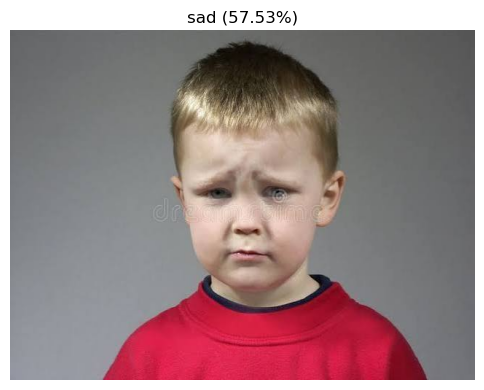

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Enter your test image path
# ----------------------------
image_path = r"C:\Users\gayat\Downloads\sad_train.jpg"
img = cv2.imread(image_path)

if img is None:
    print("Error: Unable to load image.")
else:
    # Keep original image for display
    original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Preprocess
    img = preprocess(img, "bilateral")

    # Add batch dimension
    img = np.expand_dims(img, axis=0)

    # Prediction
    prediction = model.predict(img, verbose=0)

    predicted_class = np.argmax(prediction)

    confidence = np.max(prediction) * 100

    labels = {
        0: "happy",
        1: "sad"
    }

    print("Predicted Class :", labels[predicted_class])
    print("Confidence : {:.2f}%".format(confidence))

    # Display image
    plt.figure(figsize=(6,6))
    plt.imshow(original)
    plt.title(f"{labels[predicted_class]} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()

Predicted Class : happy
Confidence : 58.38%


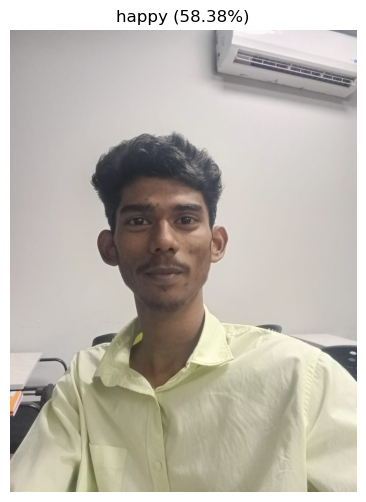

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Enter your test image path
# ----------------------------
image_path = r"C:\Users\gayat\Downloads\SANJITH.jpeg"
img = cv2.imread(image_path)

if img is None:
    print("Error: Unable to load image.")
else:
    # Keep original image for display
    original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Preprocess
    img = preprocess(img, "bilateral")

    # Add batch dimension
    img = np.expand_dims(img, axis=0)

    # Prediction
    prediction = model.predict(img, verbose=0)

    predicted_class = np.argmax(prediction)

    confidence = np.max(prediction) * 100

    labels = {
        0: "happy",
        1: "sad"
    }

    print("Predicted Class :", labels[predicted_class])
    print("Confidence : {:.2f}%".format(confidence))

    # Display image
    plt.figure(figsize=(6,6))
    plt.imshow(original)
    plt.title(f"{labels[predicted_class]} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()

Predicted Class : happy
Confidence : 88.34%


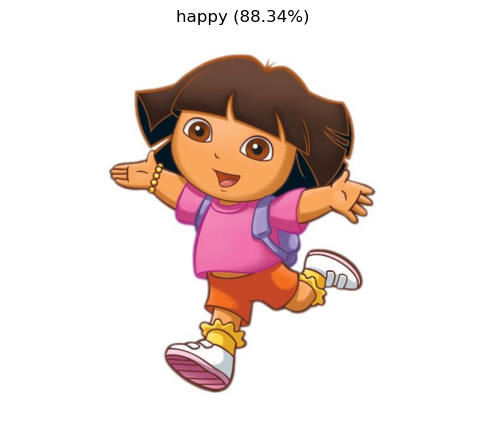

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Enter your test image path
# ----------------------------
image_path = r"C:\Users\gayat\Downloads\dor.jpg"
img = cv2.imread(image_path)

if img is None:
    print("Error: Unable to load image.")
else:
    # Keep original image for display
    original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Preprocess
    img = preprocess(img, "bilateral")

    # Add batch dimension
    img = np.expand_dims(img, axis=0)

    # Prediction
    prediction = model.predict(img, verbose=0)

    predicted_class = np.argmax(prediction)

    confidence = np.max(prediction) * 100

    labels = {
        0: "happy",
        1: "sad"
    }

    print("Predicted Class :", labels[predicted_class])
    print("Confidence : {:.2f}%".format(confidence))

    # Display image
    plt.figure(figsize=(6,6))
    plt.imshow(original)
    plt.title(f"{labels[predicted_class]} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()

In [ ]:
# 

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r"C:\Users\cathr\OneDrive\Pictures\cebb80055cd8b0d27c0374c7ec7fcec3.jpg"

img = cv2.imread(image_path)

if img is None:
    print("Error: Unable to load image.")

else:

    # Keep original image
    original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Preprocess
    img = preprocess(img, "bilateral")

    # Batch dimension
    img = np.expand_dims(img, axis=0)

    # Predict
    prediction = model.predict(img, verbose=0)

    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    labels = {
        0: "Damage",
        1: "Whole"
    }

    THRESHOLD = 80

    if confidence < THRESHOLD:
        result = "Not Found"
    else:
        result = labels[predicted_class]

    print("Prediction :", result)
    print(f"Confidence : {confidence:.2f}%")
    print("Raw Output :", prediction)

    plt.figure(figsize=(6,6))
    plt.imshow(original)
    plt.title(f"{result} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()